In [1]:
#Importación de librerías a utilizar 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Creo un dataframe con los datos del excel de la letra
df=pd.read_excel("../smoking_prediction.xlsx")

In [3]:
#Empiezo la exploración del dataset
df.head(3)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,...,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,...,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,...,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1


In [4]:
df.shape

(50000, 27)

In [5]:
#Vemos que no hay nulos y los tipos de datos que hay en cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   50000 non-null  int64  
 1   gender               50000 non-null  object 
 2   age                  50000 non-null  int64  
 3   height(cm)           50000 non-null  int64  
 4   weight(kg)           50000 non-null  int64  
 5   waist(cm)            50000 non-null  float64
 6   eyesight(left)       50000 non-null  float64
 7   eyesight(right)      50000 non-null  float64
 8   hearing(left)        50000 non-null  float64
 9   hearing(right)       50000 non-null  float64
 10  systolic             50000 non-null  float64
 11  relaxation           50000 non-null  float64
 12  fasting blood sugar  50000 non-null  float64
 13  Cholesterol          50000 non-null  float64
 14  triglyceride         50000 non-null  float64
 15  HDL                  50000 non-null 

In [6]:
#Verificamos nuevamente los nulos
df.isna().sum()/df.shape[0]*100

ID                     0.0
gender                 0.0
age                    0.0
height(cm)             0.0
weight(kg)             0.0
waist(cm)              0.0
eyesight(left)         0.0
eyesight(right)        0.0
hearing(left)          0.0
hearing(right)         0.0
systolic               0.0
relaxation             0.0
fasting blood sugar    0.0
Cholesterol            0.0
triglyceride           0.0
HDL                    0.0
LDL                    0.0
hemoglobin             0.0
Urine protein          0.0
serum creatinine       0.0
AST                    0.0
ALT                    0.0
Gtp                    0.0
oral                   0.0
dental caries          0.0
tartar                 0.0
smoking                0.0
dtype: float64

In [7]:
df.smoking.value_counts(normalize=True)*100

smoking
0    63.342
1    36.658
Name: proportion, dtype: float64

In [8]:
#Codificación y creación de train y test y dropeo la variable ID ya que no aporta valor predictivo
X = df.drop(["smoking", "ID", "tartar", "Urine protein", "oral", "hearing(left)", "hearing(right)", "dental caries", "hearing(left)", "eyesight(right)", "serum creatinine", "weight(kg)", "age", "relaxation", "AST", "systolic", "HDL", "fasting blood sugar", "ALT", "Cholesterol", "LDL", "waist(cm)", "height(cm)"], axis=1).copy()
y = df.smoking.copy()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


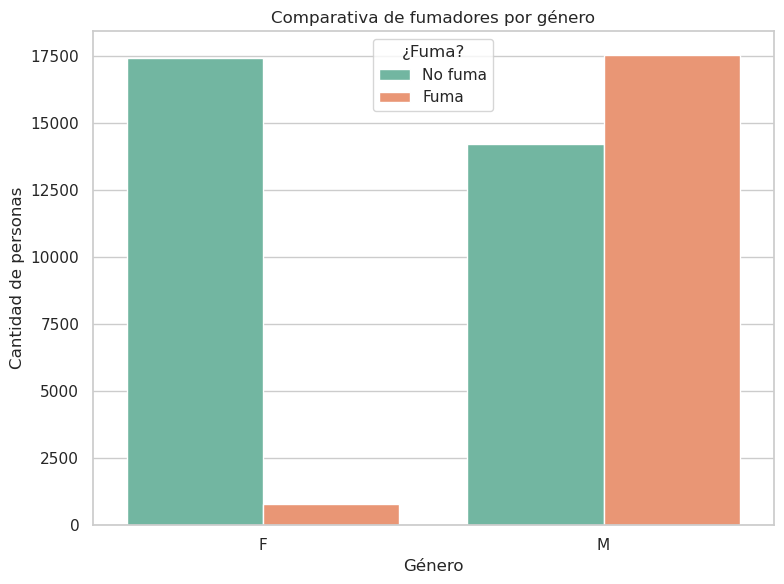

In [9]:
#Voy a hacer uan gráfica para poder representar y entender un poco mejor la composición de fumadores y no fumadores
conteo = df.groupby(['gender', 'smoking']).size().reset_index(name='count')
conteo['smoking'] = conteo['smoking'].map({0: 'No fuma', 1: 'Fuma'})
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(data=conteo, x='gender', y='count', hue='smoking', palette='Set2')
plt.title('Comparativa de fumadores por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de personas')
plt.legend(title='¿Fuma?')
plt.tight_layout()
plt.show()


In [10]:
#Empiezo la depuración en train creando variables dummies de las columnas object
from sklearn.preprocessing import OneHotEncoder

In [11]:
ohe = OneHotEncoder(sparse_output=False).fit(X_train[["gender"]])

In [12]:
encoded = ohe.transform((X_train[["gender"]]))

In [13]:
encoded_df = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded, index=X_train.index)

In [14]:
X_train = pd.concat([X_train, encoded_df], axis="columns")

In [15]:
X_train = X_train.drop(["gender"], axis=1)

In [16]:
#Replico el trabajo hecho con las dummies en el test
encoded_test = ohe.transform((X_test[["gender"]]))

In [17]:
encoded_df_test = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded_test, index=X_test.index)

In [18]:
X_test = pd.concat([X_test, encoded_df_test], axis="columns")

In [19]:
X_test = X_test.drop(["gender"], axis=1)

In [20]:
#Chequeo que ahora todas las variables sean compatibles on los árboles
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 8319 to 43737
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   eyesight(left)  35000 non-null  float64
 1   triglyceride    35000 non-null  float64
 2   hemoglobin      35000 non-null  float64
 3   Gtp             35000 non-null  float64
 4   gender_F        35000 non-null  float64
 5   gender_M        35000 non-null  float64
dtypes: float64(6)
memory usage: 1.9 MB


In [21]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 28092 to 9154
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   eyesight(left)  15000 non-null  float64
 1   triglyceride    15000 non-null  float64
 2   hemoglobin      15000 non-null  float64
 3   Gtp             15000 non-null  float64
 4   gender_F        15000 non-null  float64
 5   gender_M        15000 non-null  float64
dtypes: float64(6)
memory usage: 820.3 KB


<Axes: >

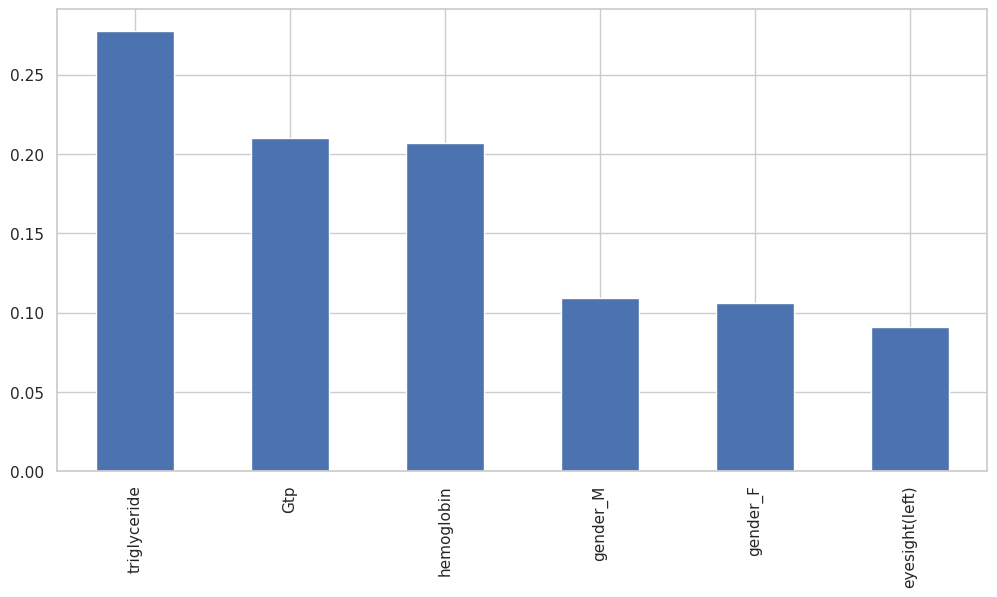

In [22]:
#Empiezo un featuring selection para un random forest, donde vemosa primera instancia que tartar, Urine protein, hearing y oral_y son las que menos influyen y variables que podríamos dropear de ser necesario.
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
importancias = pd.Series(model.feature_importances_, index=X_train.columns)
importancias.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))


In [23]:
#Creo el modelo de random forest con valores de parámetros elegidos a ojo
clf = RandomForestClassifier(n_estimators=390, min_samples_split=20, min_samples_leaf=6, random_state=42)

In [24]:
#Entreno el modelo
clf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=6, min_samples_split=20,
                       n_estimators=390, random_state=42)

In [25]:
train_pred = clf.predict(X_train)
test_pred = clf.predict(X_test)

In [26]:
from sklearn.metrics import classification_report
print("Train")
print(classification_report(y_train, train_pred))
print("----------------------------------------------------------")
print("Test")
print(classification_report(y_test, test_pred))

Train
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     22170
           1       0.77      0.82      0.79     12830

    accuracy                           0.84     35000
   macro avg       0.83      0.84      0.83     35000
weighted avg       0.85      0.84      0.84     35000

----------------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9501
           1       0.64      0.69      0.66      5499

    accuracy                           0.74     15000
   macro avg       0.72      0.73      0.73     15000
weighted avg       0.75      0.74      0.74     15000



In [27]:
#Voy a realizar lo mismo con XGBOOST para ver cual de los dos modelos trabaja mejor con mi set de datos

In [28]:
from xgboost import XGBClassifier

In [29]:
clf2 = XGBClassifier()

In [30]:
clf2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
train_pred2 = clf2.predict(X_train)
test_pred2 = clf2.predict(X_test)

In [32]:
print("Train")
print(classification_report(y_train, train_pred2))
print("----------------------------------------------------------")
print("Test")
print(classification_report(y_test, test_pred2))

Train
              precision    recall  f1-score   support

           0       0.85      0.81      0.83     22170
           1       0.70      0.76      0.73     12830

    accuracy                           0.79     35000
   macro avg       0.77      0.78      0.78     35000
weighted avg       0.79      0.79      0.79     35000

----------------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.80      0.77      0.78      9501
           1       0.62      0.67      0.65      5499

    accuracy                           0.73     15000
   macro avg       0.71      0.72      0.71     15000
weighted avg       0.74      0.73      0.73     15000



In [ ]:
#Voy a probar de nuevo el random forest utilizando la herramienta optuna para modificar los parámetros en una forma más eficiente

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 2, 100),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 50),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    model = RandomForestClassifier(**params, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

In [ ]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

In [ ]:
#Voy a correr con los parametros recomendados por el optuna
best_params = {'n_estimators': 217, 'max_leaf_nodes': 100, 'min_samples_leaf': 26, 'max_features': 0.6355666854849408, 'min_samples_split': 5}
final_model = RandomForestClassifier(**best_params, random_state=42)
final_model.fit(X_train, y_train)
train_pred3 = final_model.predict(X_train)
test_pred3 = final_model.predict(X_test)
print("Train")
print(classification_report(y_train, train_pred3))
print("----------------------------------------------------------")
print("Test")
print(classification_report(y_test, test_pred3))